<a href="https://colab.research.google.com/github/Miikezin/Ua_a1/blob/main/Sistema_de_banco_de_dados_de_loja_ATIVIDADE_3_U_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import sqlite3

In [8]:
conexao = sqlite3.connect('dados_vendas.db')

In [9]:
cursor = conexao.cursor()

In [10]:
cursor.execute('''
CREATE TABLE vendas1 (
id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
data_venda DATE,
produto TEXT,
categoria TEXT,
valor_venda REAL
)
''')

In [11]:
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')

In [12]:
conexao.commit()

In [13]:
import pandas as pd
df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

In [14]:
df_vendas.head()

,id_venda,data_venda,produto,categoria,valor_venda
0,1,2023-01-01,Produto A,Eletrônicos,1500.0
1,2,2023-01-05,Produto B,Roupas,350.0
2,3,2023-02-10,Produto C,Eletrônicos,1200.0
3,4,2023-03-15,Produto D,Livros,200.0
4,5,2023-03-20,Produto E,Eletrônicos,800.0


In [15]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     14 non-null     int64  
 1   data_venda   14 non-null     object 
 2   produto      14 non-null     object 
 3   categoria    14 non-null     object 
 4   valor_venda  14 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 692.0+ bytes


In [16]:
df_vendas.shape

(14, 5)

In [17]:
df_vendas.describe()

,id_venda,valor_venda
count,14.0000,14.000000
mean,7.5000,628.571429
std,4.1833,407.484915
min,1.0000,150.000000
25%,4.2500,312.500000
50%,7.5000,525.000000
75%,10.7500,875.000000
max,14.0000,1500.000000


In [18]:
df_vendas.columns

Index(['id_venda', 'data_venda', 'produto', 'categoria', 'valor_venda'], dtype='object')

In [19]:
nova_venda = (
    '2026-09-19',
    'Notebook',
    'Eletrônicos',
    5000.00
)

cursor.execute(
    "INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES (?, ?, ?, ?)",
    nova_venda
)

conexao.commit()

print("Venda cadastrada com sucesso!")

Venda cadastrada com sucesso!


In [25]:
import sqlite3


conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

try:
    cursor.execute("SELECT * FROM vendas1")
    vendas = cursor.fetchall()

    print("Vendas Cadastradas:")
    for venda in vendas:
        print(venda)
except Exception as e:
    print(f"Ocorreu um erro ao consultar as vendas: {e}")
finally:
    if conexao:
        conexao.close()

Vendas Cadastradas:
(1, '2023-01-01', 'Produto A', 'Eletrônicos', 1500.0)
(2, '2023-01-05', 'Produto B', 'Roupas', 350.0)
(3, '2023-02-10', 'Produto C', 'Eletrônicos', 1200.0)
(4, '2023-03-15', 'Produto D', 'Livros', 200.0)
(5, '2023-03-20', 'Produto E', 'Eletrônicos', 800.0)
(6, '2023-04-02', 'Produto F', 'Roupas', 400.0)
(7, '2023-05-05', 'Produto G', 'Livros', 150.0)
(8, '2023-06-10', 'Produto H', 'Eletrônicos', 1000.0)
(9, '2023-07-20', 'Produto I', 'Roupas', 600.0)
(10, '2023-08-25', 'Produto J', 'Eletrônicos', 700.0)
(11, '2023-09-30', 'Produto K', 'Livros', 300.0)
(12, '2023-10-05', 'Produto L', 'Roupas', 450.0)
(13, '2023-11-15', 'Produto M', 'Eletrônicos', 900.0)
(14, '2023-12-20', 'Produto N', 'Livros', 250.0)
(15, '2026-09-19', 'Notebook', 'Eletrônicos', 5000.0)


In [27]:
import sqlite3

conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

atualizacao = (
    'Notebook Dell',
    5500.00,
    1
)

try:
    cursor.execute(
        "UPDATE vendas1 SET produto = ?, valor_venda = ? WHERE id_venda = ?",
        atualizacao
    )
    conexao.commit()
    print("Venda atualizada com sucesso!")
except Exception as e:
    print(f"Ocorreu um erro ao atualizar a venda: {e}")
finally:
    if conexao:
        conexao.close()

Venda atualizada com sucesso!


In [29]:
import sqlite3

conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

id_venda_para_deletar = 1

try:
    cursor.execute(
        "DELETE FROM vendas1 WHERE id_venda = ?",
        (id_venda_para_deletar,)
    )
    conexao.commit()
    print("Venda deletada com sucesso!")
except Exception as e:
    print(f"Ocorreu um erro ao deletar a venda: {e}")
finally:
    if conexao:
        conexao.close()

Venda deletada com sucesso!


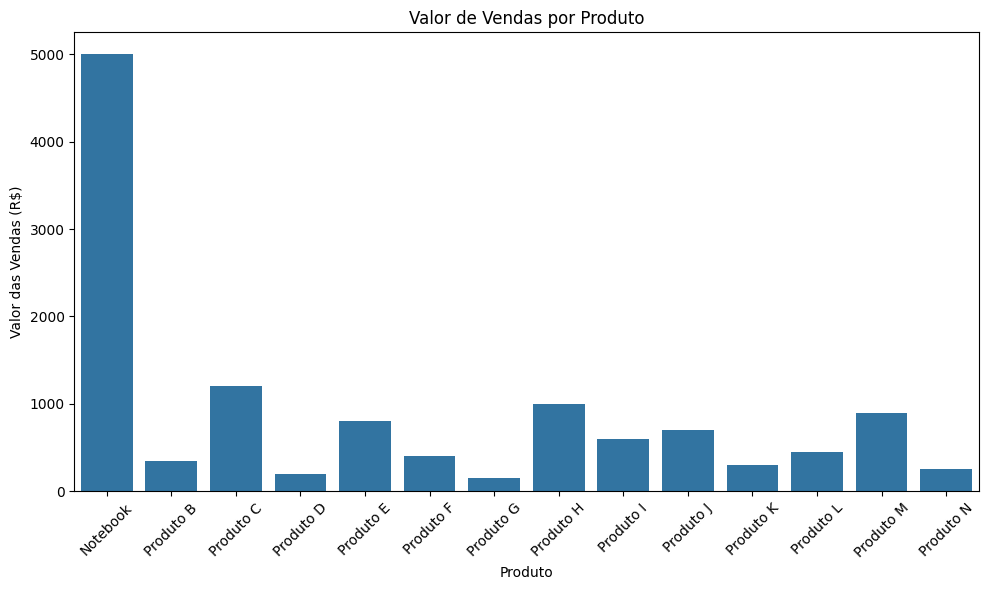

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sqlite3


conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

try:

    cursor.execute("SELECT * FROM vendas1")
    vendas = cursor.fetchall()


    df_vendas = pd.DataFrame(
        vendas,
        columns=[
            'id_venda',
            'data_venda',
            'produto',
            'categoria',
            'valor_venda'
        ]
    )


    vendas_produto = df_vendas.groupby('produto')['valor_venda'].sum().reset_index()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=vendas_produto,
        x='produto',
        y='valor_venda'
    )

    plt.title('Valor de Vendas por Produto')
    plt.xlabel('Produto')
    plt.ylabel('Valor das Vendas (R$)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico: {e}")
finally:
    if conexao:
        conexao.close()